 # Opdracht 2: Imports en Data Laden

In [223]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Lees de dataset in
df = pd.read_csv('AmesHousing.csv')


 # Opdracht 3: Data Schoonmaken en Feature Engineering

In [ ]:
# Verwijder extreme uitschieters
df = df[df['Gr Liv Area'] < 4000].copy()

target = 'SalePrice'

features = [
    'Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Year Built', 'Full Bath', 'Bedroom AbvGr', 'Neighborhood'
]

df_subset = df[features + [target]].copy()

# Vul ontbrekende numerieke waarden op met 0 (bijv. geen kelder of geen garage)
df_subset.fillna(0, inplace=True)


,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,SalePrice
0,6,1656,1080.0,31770,1960,1,3,NAmes,215000
1,5,896,882.0,11622,1961,1,2,NAmes,105000
2,6,1329,1329.0,14267,1958,1,3,NAmes,172000
3,7,2110,2110.0,11160,1968,2,3,NAmes,244000
4,5,1629,928.0,13830,1997,2,3,Gilbert,189900
...,...,...,...,...,...,...,...,...,...
2925,6,1003,1003.0,7937,1984,1,3,Mitchel,142500
2926,5,902,864.0,8885,1983,1,2,Mitchel,131000
2927,5,970,912.0,10441,1992,1,3,Mitchel,132000
2928,5,1389,1389.0,10010,1974,1,2,Mitchel,170000


 # Opdracht 4: Data Voorbereiding

In [ ]:
# One-hot encode de categorische features
X = pd.get_dummies(df_subset[features], drop_first=True)

# Log-transformatie op de target variabele (SalePrice)
# np.log1p berekent log(1 + x) en voorkomt problemen met nullen
y = np.log1p(df_subset[target])

# Splits de dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=184871)

# Scaling (Cruciaal voor SGDRegressor)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data: {X_train_scaled.shape[0]} huizen")
print(f"Test data: {X_test_scaled.shape[0]} huizen")

Training data: 2340 huizen
Test data: 585 huizen


 # Opdracht 5: Model Training

In [ ]:
epochs = 4
learning_rate = 0.005

# L2 penalty (Ridge) om overfitting op de nieuwe features te voorkomen
model = SGDRegressor(
    loss='squared_error',
    penalty='l2',
    alpha=0.01,
    eta0=learning_rate,
    random_state=184871
)

train_errors = []
test_errors = []

print("Training gestart...")
for epoch in range(epochs):
    # Train het model voor 1 epoch op de LOG-getransformeerde prijzen
    model.partial_fit(X_train_scaled, y_train)

    # Voorspellingen in log-formaat
    y_train_pred_log = model.predict(X_train_scaled)
    y_test_pred_log = model.predict(X_test_scaled)

    # Transformeer terug naar dollars (np.expm1 is het tegenovergestelde van np.log1p)
    # Dit doen we zodat de leercuve de fout in ECHTE dollars laat zien
    y_train_pred_dollars = np.expm1(y_train_pred_log)
    y_test_pred_dollars = np.expm1(y_test_pred_log)

    y_train_dollars = np.expm1(y_train)
    y_test_dollars = np.expm1(y_test)

    # Bereken RMSE in dollars
    train_rmse = np.sqrt(mean_squared_error(y_train_dollars, y_train_pred_dollars))
    test_rmse = np.sqrt(mean_squared_error(y_test_dollars, y_test_pred_dollars))

    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

print("Training voltooid!")

Training gestart...
Training voltooid!


 # Opdracht 6: Evaluatie

In [227]:
# Maak de definitieve voorspellingen
y_pred_log = model.predict(X_test_scaled)

# Transformeer voorspellingen en werkelijke waarden terug naar dollars voor de metrieken
y_pred_dollars = np.expm1(y_pred_log)
y_test_dollars = np.expm1(y_test)

mse = mean_squared_error(y_test_dollars, y_pred_dollars)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_dollars, y_pred_dollars)
r2 = r2_score(y_test_dollars, y_pred_dollars)

print("\n--- Verbeterde Resultaten ---")
print(f"R-squared: {r2:.4f}")
print(f"Root Mean Squared Error: ${rmse:,.2f}")
print(f"Mean Absolute Error:     ${mae:,.2f}")



--- Verbeterde Resultaten ---
R-squared: 0.9207
Root Mean Squared Error: $22,345.96
Mean Absolute Error:     $16,459.48


 # Visualisatie van de resultaten

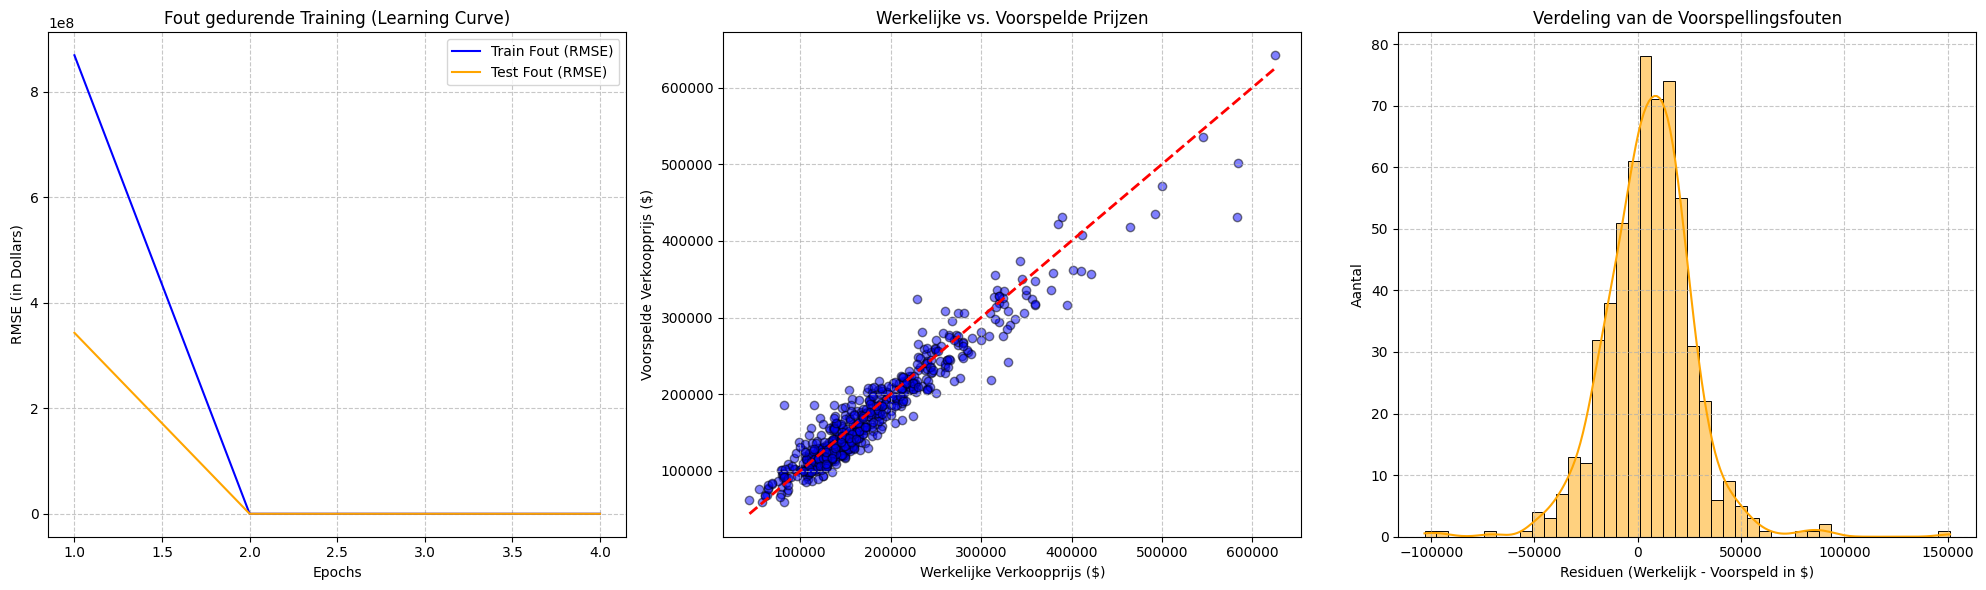

In [228]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# Grafiek 1: Learning Curve
ax[0].plot(range(1, epochs + 1), train_errors, label='Train Fout (RMSE)', color='blue')
ax[0].plot(range(1, epochs + 1), test_errors, label='Test Fout (RMSE)', color='orange')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('RMSE (in Dollars)')
ax[0].set_title('Fout gedurende Training (Learning Curve)')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.7)

# Grafiek 2: Werkelijke vs Voorspelde prijzen
ax[1].scatter(y_test_dollars, y_pred_dollars, alpha=0.5, color='blue', edgecolor='k')
# Rode stippellijn
ax[1].plot([y_test_dollars.min(), y_test_dollars.max()],
           [y_test_dollars.min(), y_test_dollars.max()], '--r', linewidth=2)
ax[1].set_xlabel('Werkelijke Verkoopprijs ($)')
ax[1].set_ylabel('Voorspelde Verkoopprijs ($)')
ax[1].set_title('Werkelijke vs. Voorspelde Prijzen')
ax[1].grid(True, linestyle='--', alpha=0.7)

# Grafiek 3: Distributie van de residuen
residuals = y_test_dollars - y_pred_dollars
sns.histplot(residuals, kde=True, ax=ax[2], color='orange')
ax[2].set_xlabel('Residuen (Werkelijk - Voorspeld in $)')
ax[2].set_ylabel('Aantal')
ax[2].set_title('Verdeling van de Voorspellingsfouten')
ax[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()